In [1]:
from torch.nn import Linear
from torch_geometric.nn import GCNConv, GINConv, global_add_pool
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

torch.manual_seed(42)

/Users/marlene/Documents/data/Projects/17_try_neural_networks/Code/Graph_learning_task/graph_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task: Expressivity and the Lottery Ticket Hypothesis

To shed light on the intricate interplay between expressivity and the LTH for GNNs, proceed as follows:

**(a)** Explore the expressivity of **untrained randomly initialized GNNs** and the effect when pruning is applied to them (i.e., the initial weights are sparsified by setting elements to zero).

* **(i)** Devise a method $M(\Phi, D)$ to empirically determine the expressivity of a given GNN $\Phi$ on a given dataset $D$ for both nodes and graphs.

For this purpose we will choose the **Empirical Distinguishability Score**

To quantify the expressivity of an untrained, pruned GNN $\Phi$ on a dataset $D$, we measure its ability to assign unique embedding vectors to structurally distinct inputs. This method is grounded in the Weisfeiler-Lehman (1-WL) isomorphism test.

### 1. Preliminaries
* Let $D = \{x_1, x_2, \dots, x_N\}$ be the set of inputs (where $x_i$ can be a node or a graph).
* Let $\Phi(x; \theta, m)$ be the GNN with random initialization $\theta$ and a binary pruning mask $m$.
* Let $h_i = \Phi(x_i)$ be the output embedding for input $x_i$.

### 2. Pairwise Distinguishability
We define the **Distinguishability Indicator** $\delta(i, j)$ for a pair of inputs. The GNN successfully distinguishes the pair if their embeddings are separated by more than a numerical tolerance $\epsilon$ (e.g., $\epsilon = 10^{-5}$).

$$
\delta(i, j) = \mathbb{1}(||h_i - h_j||_2 > \epsilon)
$$

### 3. Empirical Distinguishability Score
The Empirical Distinguishability Score (EDS) is computed as the ratio of distinguishable pairs to the total number of pairs:

$$
E(\Phi, D) = \frac{\sum_{i < j, c_i \neq c_j} \delta(i, j)}{\sum_{i < j} \mathbb{1}(c_i \neq c_j)}
$$

#### Interpretation
* **$E = 1.0$**: The pruned GNN $\Phi$ is **Fully Expressive**. It retains enough capacity to separate all inputs that a dense 1-WL equivalent network could separate.
* **$E < 1.0$**: The GNN suffers from **Embedding Collapse**. The pruning has removed critical pathways, causing distinct graph structures to map to identical representations.

In [2]:
class GNN(torch.nn.Module):
    def __init__(self, input_dim=1433,output_dim=7, hidden_channels=16, num_layers=3, dropout=0.5,inner_layers=lambda in_c, out_c: GCNConv(in_c, out_c, bias = False),output_layer=lambda in_c, out_c: Linear(in_c, out_c, bias = False)):
        super(GNN, self).__init__()
        self.convs = torch.nn.ModuleList()
        self.convs.append(inner_layers(input_dim, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(inner_layers(hidden_channels, hidden_channels))
        self.convs.append(inner_layers(hidden_channels, hidden_channels))
        self.dropout = dropout
        self.output_layer = output_layer(hidden_channels, output_dim)

    def forward(self, x, edge_index, batch=None):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = torch.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.convs[-1](x, edge_index)
        # Default to all nodes being in one graph if batch is missing
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        x = global_add_pool(x, batch)

        x = self.output_layer(x)
        return x

class GIN(GNN):
    def __init__(self, input_dim=1433,output_dim=7, hidden_channels=16, num_layers=2, dropout=0.5):
        super(GIN, self).__init__(input_dim,output_dim, hidden_channels, num_layers, dropout,inner_layers=lambda in_c,out_c: GINConv(Linear(in_c,out_c, bias = False)),output_layer=lambda in_c, out_c: Linear(in_c, out_c, bias=False))




def EMD(phi:GNN,D,eps=10e-5):
    delta = lambda x,y: np.linalg.norm(x-y) > eps
    phi.eval()
    embeddings = []
    with torch.no_grad():
        for data in D:
            out = phi(data.x, data.edge_index)
            embeddings.append(out.squeeze().cpu().numpy())
    ind = np.triu_indices(len(D),k=1)
    dist_pairs = 0
    for i,j in zip(ind[0],ind[1]):
        dist_pairs += delta(embeddings[i], embeddings[j]).astype(int)
    return dist_pairs / (len(D)*(len(D)-1)/2)
        

**(ii)** Use a 3-layer **Graph Isomorphism Network (GIN)** and a **Graph Convolutional Network (GCN)** for $\Phi$ with a random initialization and activation functions of your choice.

Write code to randomly prune a given fraction
$$
\rho \in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
$$
of weight elements.

If you use Python and PyTorch Geometric, you can, for example, access and prune the models’ weights as follows:

```python
for name, param in model.named_parameters():
    # Variable name usually contains
    # type and position of a layer.
    if 'conv' in name:
        # Only prune the trainable weights.
        if 'weight' in name and param.requires_grad:
            # Generate a random pruning mask
            pruning_mask = ...
            # Apply via elementwise product *
            # and write back to the param storage.
            param.data.copy_(pruning_mask * param.data)

In [3]:
def prune_GNN(phi:GNN, p=0.5):
    for name, param in phi.named_parameters():
        if 'weight' in name:
            mask = torch.rand_like(param) > p
            param.data.mul_(mask)
    return phi

**(iii)** After completing the previous steps, evaluate M for both models and all values of ρ given above and
the datasets MUTAG, PTC FM and ENZYMES. Always use the whole dataset without splitting.
Filter out copies of isomorphic graphs, i.e., only keep one instance of each isomorphism type,5 and
rerun the experiments.

Loading the datasets, without cleaning to run with isomorphic graphs.

In [4]:
from torch_geometric.datasets import TUDataset

mutag = TUDataset(root='data/TUDataset', name='MUTAG')
ptc_fm = TUDataset(root='data/TUDataset', name='PTC_FM')
enzymes = TUDataset(root='data/TUDataset', name='ENZYMES')


In [5]:
# Remove isomorphic graphs
from torch_geometric.utils import to_networkx
import networkx as nx

def filter_isomorphisms(dataset):
    hashes = set()
    unique_data = []
    
    print(f"Filtering {len(dataset)} graphs.")
    for data in dataset:
        G = to_networkx(data, to_undirected=True)
        g_hash = nx.weisfeiler_lehman_graph_hash(G)
        
        if g_hash not in hashes:
            hashes.add(g_hash)
            unique_data.append(data)
            
    print(f"Kept {len(unique_data)} unique graphs.")
    return unique_data

In [6]:
# Define
emd_eps = 0.1
output_dim = hidden_dim = 16

# Pruning List
rho_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]

# Iterate twice: Condition 'Original' (with isomorphic graphs) and 'Filtered' (without isomorphic graphs)
results = []
seeds = [0, 1, 2, 3, 4]  # Run 5 times

for seed in seeds:
    for condition in ['Original', 'Filtered']:
        for ds_raw in [mutag, ptc_fm, enzymes]:
            
            # Apply filtering if second pass
            if condition == 'Filtered':
                dataset = filter_isomorphisms(ds_raw)
            else:
                dataset = ds_raw
                
            ds_name = ds_raw.name
            num_classes = ds_raw.num_classes
            in_dim = ds_raw.num_node_features
            
            print(f"Processing {ds_name} ({condition})...")

            for p in rho_values:
                # Run GCN
                gcn = GNN(input_dim=in_dim, output_dim=output_dim, hidden_channels=hidden_dim, num_layers=3, dropout=0.0)
                gcn = prune_GNN(gcn, p=p)
                score_gcn = EMD(gcn, dataset, eps = emd_eps)

                # Run GIN
                gin = GIN(input_dim=in_dim, output_dim=output_dim, hidden_channels=hidden_dim, num_layers=3, dropout=0.0)
                gin = prune_GNN(gin, p=p)
                score_gin = EMD(gin, dataset, eps = emd_eps)

                # Store
                results.append({
                    'Dataset': ds_name,
                    'Condition': condition,
                    'Pruning_Level': p,
                    'Model': 'GCN',
                    'Score': score_gcn
                })
                results.append({
                    'Dataset': ds_name,
                    'Condition': condition,
                    'Pruning_Level': p,
                    'Model': 'GIN',
                    'Score': score_gin
                })

df_results = pd.DataFrame(results)

Processing MUTAG (Original)...
Processing PTC_FM (Original)...
Processing ENZYMES (Original)...
Filtering 188 graphs.
Kept 135 unique graphs.
Processing MUTAG (Filtered)...


/Users/marlene/Documents/data/Projects/17_try_neural_networks/Code/Graph_learning_task/graph_learning/.venv/lib/python3.13/site-packages/networkx/algorithms/graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributes changed in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)


Filtering 349 graphs.
Kept 263 unique graphs.
Processing PTC_FM (Filtered)...
Filtering 600 graphs.
Kept 595 unique graphs.
Processing ENZYMES (Filtered)...
Processing MUTAG (Original)...
Processing PTC_FM (Original)...
Processing ENZYMES (Original)...
Filtering 188 graphs.
Kept 135 unique graphs.
Processing MUTAG (Filtered)...
Filtering 349 graphs.
Kept 263 unique graphs.
Processing PTC_FM (Filtered)...
Filtering 600 graphs.
Kept 595 unique graphs.
Processing ENZYMES (Filtered)...
Processing MUTAG (Original)...
Processing PTC_FM (Original)...
Processing ENZYMES (Original)...
Filtering 188 graphs.
Kept 135 unique graphs.
Processing MUTAG (Filtered)...
Filtering 349 graphs.
Kept 263 unique graphs.
Processing PTC_FM (Filtered)...
Filtering 600 graphs.
Kept 595 unique graphs.
Processing ENZYMES (Filtered)...
Processing MUTAG (Original)...
Processing PTC_FM (Original)...
Processing ENZYMES (Original)...
Filtering 188 graphs.
Kept 135 unique graphs.
Processing MUTAG (Filtered)...
Filtering 

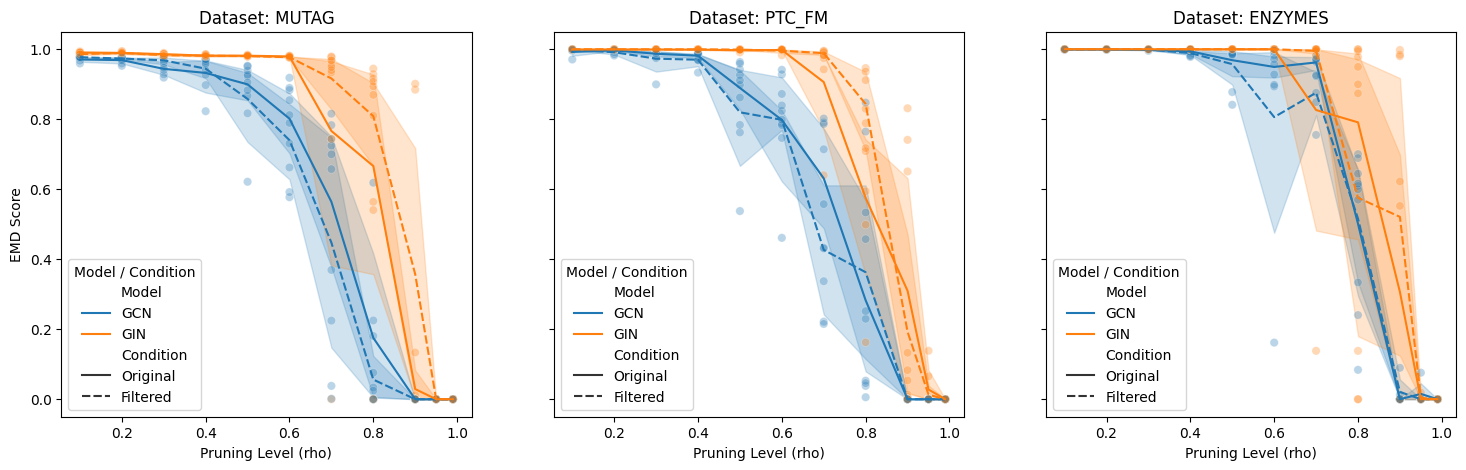

In [7]:
import seaborn as sns

df = df_results.copy()
datasets = df['Dataset'].unique()

fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), sharey=True)

for ax, ds in zip(axes, datasets):
    sns.lineplot(
        data=df[df['Dataset'] == ds], 
        x='Pruning_Level', 
        y='Score', 
        hue='Model', 
        style='Condition',
        ax=ax
    )
    sns.scatterplot(
        data=df[df['Dataset'] == ds], 
        x='Pruning_Level', y='Score', 
        hue='Model', 
        alpha=0.3, 
        legend=False, 
        ax = ax)
    ax.set_title(f"Dataset: {ds}")
    ax.set_xlabel("Pruning Level (rho)")
    ax.set_ylabel("EMD Score")
    ax.legend(title='Model / Condition')


In [8]:
# Create column for combined Model and Condition for plotting
df_results['Model_Condition'] = df_results['Model'] + " (" + df_results['Condition'] + ")"

palette = {
    'GCN (Original)': '#a6cee3', 'GCN (Filtered)': '#1f78b4',
    'GIN (Original)': '#fb9a99', 'GIN (Filtered)': '#e31a1c'
}

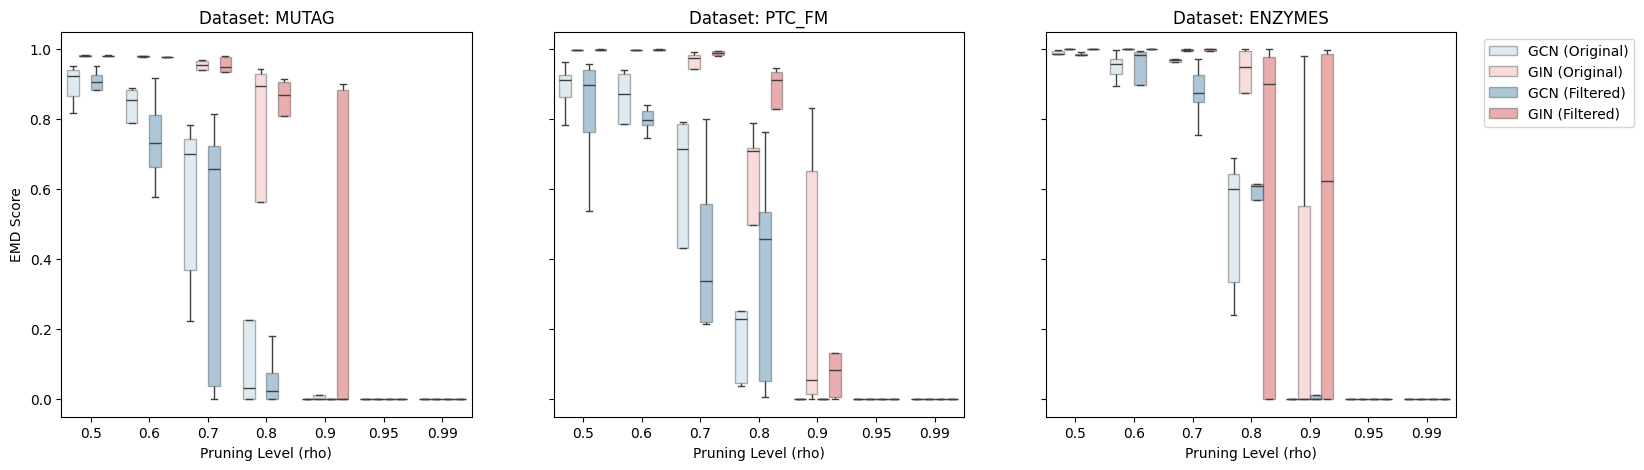

In [9]:
subset = df_results[df_results['Pruning_Level'] >= 0.5]
fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), sharey=True)


for ax, ds in zip(axes, datasets):
    sns.boxplot(data=subset[subset['Dataset'] == ds], x='Pruning_Level', y='Score', hue='Model_Condition', palette=palette, fliersize=0, boxprops={'alpha': 0.4}, ax=ax)
    ax.set_title(f"Dataset: {ds}")
    ax.set_xlabel("Pruning Level (rho)")
    ax.set_ylabel("EMD Score")

    if ds == datasets[-1]:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

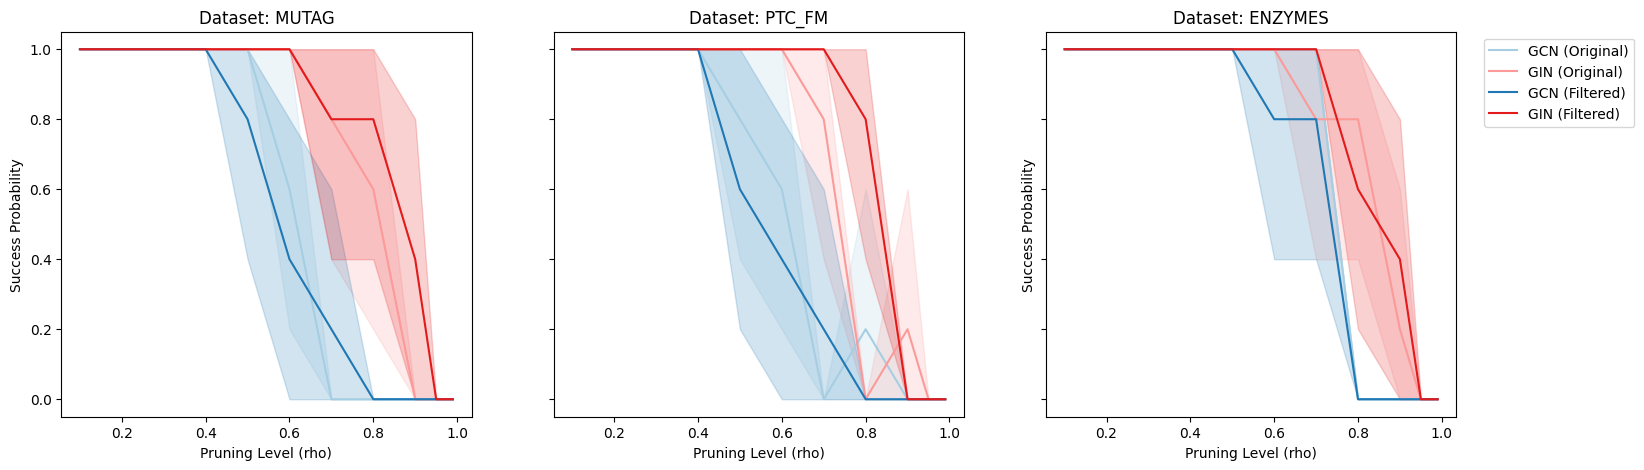

In [10]:
# "Success" as EDS > 0.8 
df_results['Success'] = df_results['Score'] > 0.8

fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), sharey=True)

for ax, ds in zip(axes, datasets):
    sns.lineplot(data=df_results[df_results['Dataset'] == ds], x='Pruning_Level', y='Success', hue='Model_Condition', palette=palette, ax=ax)
    plt.ylabel("Probability of Winning Ticket (Score > 0.8)")
    ax.set_title(f"Dataset: {ds}")
    ax.set_xlabel("Pruning Level (rho)")
    ax.set_ylabel("Success Probability")

    if ds == datasets[-1]:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

## **(b)** Explore the relationship between the expressivity of the untrained and pruned GNNs and their post-training prediction quality.

- **(i)**: For each of the models, datasets, and pruning ratios from (a), train the model for 100 epochs, but
do not remove isomorphic graphs this time. Measure the training prediction quality of the GNN
using some method A(Φ, D). Do not split the dataset as test prediction quality is not relevant for
this task. Ensure that only those weights that were not pruned after initialization are trained. You
can achieve this by applying the pruning mask you created at the beginning, either to the weights
before every forward pass or to the gradients before every update step.

Training prediction quality A(Φ, D) will be measured by comparing the categorization of the model to the actual categorys.

In [11]:
def create_masks(model):
    masks = {}
    for name, param in model.named_parameters():
        if 'conv' in name and 'weight' in name:
            # Create mask: 1 where weight != 0, else 0
            mask = (param != 0).float()
            masks[name] = mask
    return masks

In [12]:
from torch_geometric.loader import DataLoader

def train_and_evaluate(model, dataset, epochs=100, lr=0.01):
    # Use whole dataset for training
    loader = DataLoader(dataset, batch_size=64, shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()
    
    # Create masks based on the current pruning state
    masks = create_masks(model)
    
    model.train()
    
    # Training Loop
    for epoch in range(epochs):
        for batch in loader:
            optimizer.zero_grad()
            
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            loss.backward()
            
            # Mask the gradients of pruned weights to be 0
            for name, param in model.named_parameters():
                if name in masks:
                    # multiply by mask (0 or 1)
                    param.grad.mul_(masks[name])
            
            optimizer.step()
            
    # measure how well model learned the data it trained on
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1) 
            correct += (pred == batch.y).sum().item()
            total += batch.y.size(0)
            
    return correct / total

In [13]:
train_results = []
rho_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]

torch.manual_seed(42)

for ds in [mutag, ptc_fm, enzymes]:
    ds_name = ds.name
    print(f"--- Training on {ds_name} ---")
    
    for p in rho_values:
        # ---------------- GCN ----------------
        # Output dim is now number of classes, no longer hidden dim
        gcn = GNN(input_dim=ds.num_node_features, 
                  output_dim=ds.num_classes,
                  hidden_channels=16, 
                  num_layers=3)
        
        gcn = prune_GNN(gcn, p=p)
        acc_gcn = train_and_evaluate(gcn, ds)
        
        # ---------------- GIN ----------------
        gin = GIN(input_dim=ds.num_node_features, 
                  output_dim=ds.num_classes, 
                  hidden_channels=16, 
                  num_layers=3)
        
        gin = prune_GNN(gin, p=p)
        acc_gin = train_and_evaluate(gin, ds)

        train_results.append({'Dataset': ds_name, 'Model': 'GCN', 'Pruning_Level': p, 'Accuracy': acc_gcn})
        train_results.append({'Dataset': ds_name, 'Model': 'GIN', 'Pruning_Level': p, 'Accuracy': acc_gin})

df_training = pd.DataFrame(train_results)

--- Training on MUTAG ---
--- Training on PTC_FM ---
--- Training on ENZYMES ---


**(ii)** Apply your code of task (a, iii) to the trained models.

In [14]:
final_results = []
rho_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
eps_threshold = 0.1

seeds = [0, 1, 2, 3, 4]  # Run 5 times

for seed in seeds:

    for ds_raw in [mutag, ptc_fm, enzymes]:
        
        ds_name = ds_raw.name
        print(f"--- Processing {ds_name} ---")
        
        # Using full dataset for training
        train_dataset = ds_raw 
        
        # Filtered dataset for expressivity
        expressivity_dataset = filter_isomorphisms(ds_raw)

        for p in rho_values:
            # ---------------- GCN ----------------
            # Output dim is now number of classes, not hidden dim
            gcn = GNN(input_dim=ds_raw.num_node_features, 
                    output_dim=ds_raw.num_classes, 
                    hidden_channels=16, 
                    num_layers=3)
            
            gcn = prune_GNN(gcn, p=p)
            train_acc_gcn = train_and_evaluate(gcn, train_dataset, epochs=100)
            exp_score_gcn = EMD(gcn, expressivity_dataset, eps=eps_threshold)
            
            # ---------------- GIN ----------------
            gin = GIN(input_dim=ds_raw.num_node_features, 
                    output_dim=ds_raw.num_classes, 
                    hidden_channels=16, 
                    num_layers=3)
            
            gin = prune_GNN(gin, p=p)
            train_acc_gin = train_and_evaluate(gin, train_dataset, epochs=100)
            exp_score_gin = EMD(gin, expressivity_dataset, eps=eps_threshold)

            final_results.append({
                'Dataset': ds_name,
                'Model': 'GCN',
                'Pruning_Level': p,
                'Train_Accuracy': train_acc_gcn,
                'Trained_Expressivity': exp_score_gcn
            })
            
            final_results.append({
                'Dataset': ds_name,
                'Model': 'GIN',
                'Pruning_Level': p,
                'Train_Accuracy': train_acc_gin,
                'Trained_Expressivity': exp_score_gin
            })

    df_final = pd.DataFrame(final_results)

--- Processing MUTAG ---
Filtering 188 graphs.
Kept 135 unique graphs.


/Users/marlene/Documents/data/Projects/17_try_neural_networks/Code/Graph_learning_task/graph_learning/.venv/lib/python3.13/site-packages/networkx/algorithms/graph_hashing.py:211: UserWarning: The hashes produced for graphs without node or edge attributes changed in v3.5 due to a bugfix (see documentation).
  node_labels = _init_node_labels(G, edge_attr, node_attr)


--- Processing PTC_FM ---
Filtering 349 graphs.
Kept 263 unique graphs.
--- Processing ENZYMES ---
Filtering 600 graphs.
Kept 595 unique graphs.
--- Processing MUTAG ---
Filtering 188 graphs.
Kept 135 unique graphs.
--- Processing PTC_FM ---
Filtering 349 graphs.
Kept 263 unique graphs.
--- Processing ENZYMES ---
Filtering 600 graphs.
Kept 595 unique graphs.
--- Processing MUTAG ---
Filtering 188 graphs.
Kept 135 unique graphs.
--- Processing PTC_FM ---
Filtering 349 graphs.
Kept 263 unique graphs.
--- Processing ENZYMES ---
Filtering 600 graphs.
Kept 595 unique graphs.
--- Processing MUTAG ---
Filtering 188 graphs.
Kept 135 unique graphs.
--- Processing PTC_FM ---
Filtering 349 graphs.
Kept 263 unique graphs.
--- Processing ENZYMES ---
Filtering 600 graphs.
Kept 595 unique graphs.
--- Processing MUTAG ---
Filtering 188 graphs.
Kept 135 unique graphs.
--- Processing PTC_FM ---
Filtering 349 graphs.
Kept 263 unique graphs.
--- Processing ENZYMES ---
Filtering 600 graphs.
Kept 595 unique

**(iii)** Visualize your results in combination with your results from (a) and (optionally) explore the statistical significance of the relation between A(Φ, D) and M(Φ, D), where M is once measured before training (use your results from (a, iii)), and once after training (use your results from (b, ii)).

In [15]:
# For plotting both trained and untrained expressivvity together
df_untrained = df_results[df_results['Condition'] == 'Filtered'].copy()
df_untrained = df_untrained[['Dataset', 'Model', 'Pruning_Level', 'Score']]
df_untrained = df_untrained.rename(columns={'Score': 'Untrained_Expressivity'})

# Merge on Dataset, Model, Pruning_Level
df_combined = pd.merge(
    df_final, 
    df_untrained, 
    on=['Dataset', 'Model', 'Pruning_Level'], 
    how='inner'
)

# Melt to long format
df_long_all = df_combined.melt(
    id_vars=['Dataset', 'Model', 'Pruning_Level'],
    value_vars=['Train_Accuracy', 'Trained_Expressivity', 'Untrained_Expressivity'],
    var_name='Metric',
    value_name='Score'
)

# Rename for nicer labels
df_long_all['Metric'] = df_long_all['Metric'].replace({
    'Train_Accuracy': 'Accuracy',
    'Trained_Expressivity': 'Trained Exp.',
    'Untrained_Expressivity': 'Untrained Exp.'
})

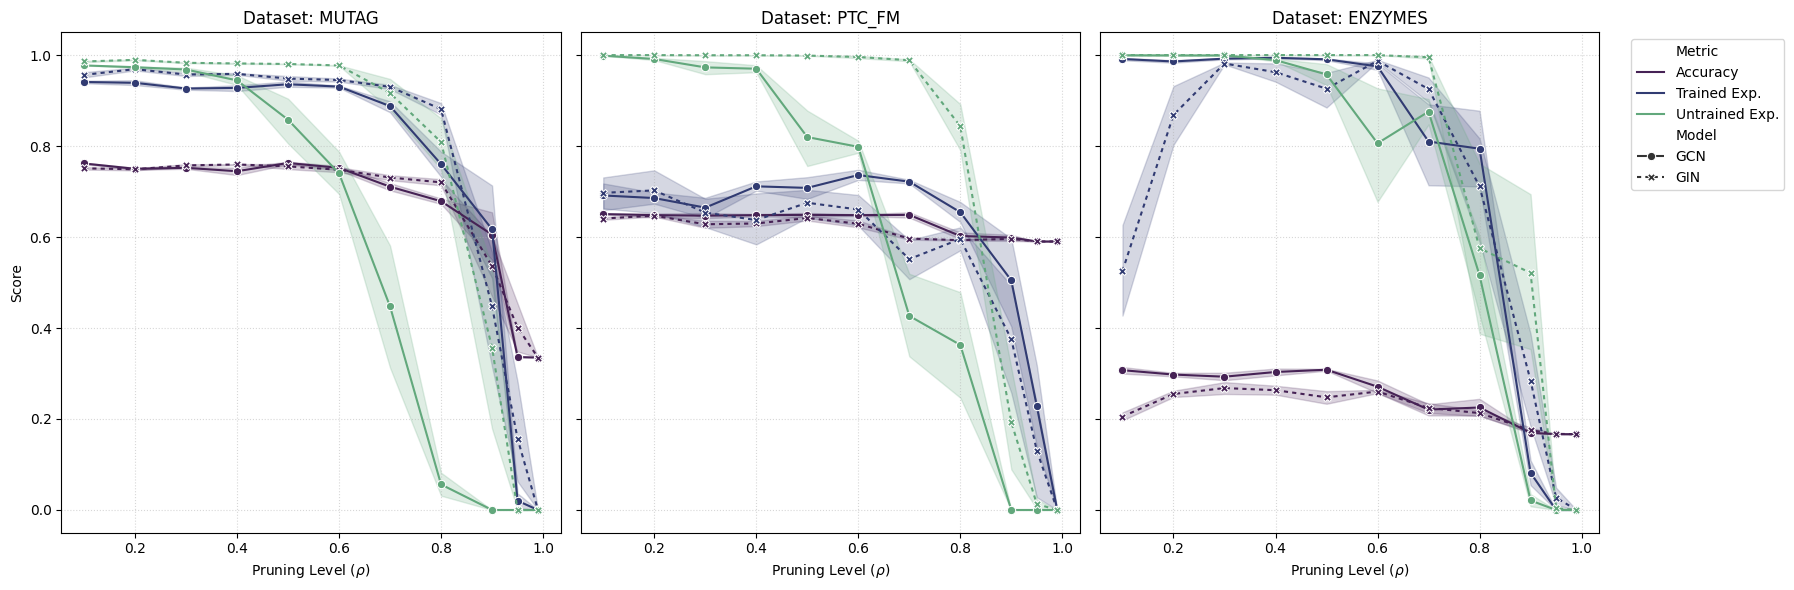

In [16]:
# Comparing the expressivity of trained and untrained together with the accuracy of the trained model
datasets = df_long_all['Dataset'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Palette is Metric, Style is Model
palette = {'Accuracy': '#462255', 'Trained Exp.': '#313B72', 'Untrained Exp.': '#62A87C'}
dashes = {'GCN': (1,0), 'GIN': (2,2)}


for ax, ds in zip(axes, datasets):
    subset = df_long_all[df_long_all['Dataset'] == ds]
    
    sns.lineplot(
        data=subset,
        x='Pruning_Level',
        y='Score',
        hue='Metric',
        style='Model',
        palette=palette,
        dashes=dashes,
        markers=True,
        ax=ax
    )
    
    ax.set_title(f"Dataset: {ds}")
    ax.set_xlabel(r'Pruning Level ($\rho$)')
    ax.set_ylabel("Score")
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # Legend handling
    if ds == datasets[-1]:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

This plot shows expressivity of both the trained and untrained model. For the trained one expressivity is often lower as we are only mapping to the number of classes in the dataset vs. the untrained one has the dimension of the hidden layer (16). 

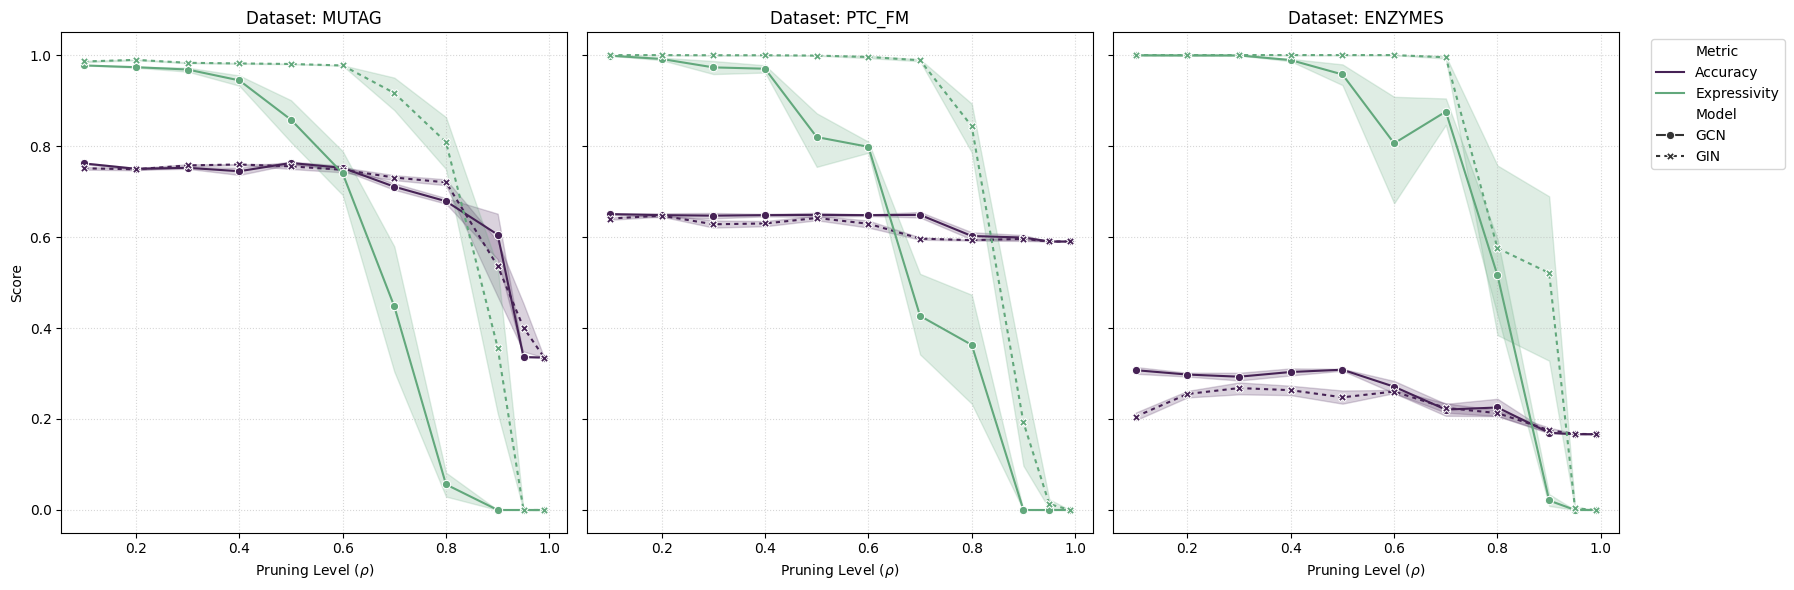

In [17]:
# Comparing the expressivity of only the untrained model with the accuracy of the trained model
df_expr_vs_acc = df_long_all[df_long_all['Metric'].isin(['Accuracy', 'Untrained Exp.'])]
df_expr_vs_acc = df_expr_vs_acc.replace({'Metric': {'Untrained Exp.': 'Expressivity'}})

datasets = df_expr_vs_acc['Dataset'].unique()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Palette is Metric, Style is Model
palette = {'Accuracy': '#462255', 'Expressivity': '#62A87C'}
dashes = {'GCN': (1,0), 'GIN': (2,2)}


for ax, ds in zip(axes, datasets):
    subset = df_expr_vs_acc[df_expr_vs_acc['Dataset'] == ds]
    
    sns.lineplot(
        data=subset,
        x='Pruning_Level',
        y='Score',
        hue='Metric',
        style='Model',
        palette=palette,
        dashes=dashes,
        markers=True,
        ax=ax
    )
    
    ax.set_title(f"Dataset: {ds}")
    ax.set_xlabel(r'Pruning Level ($\rho$)')
    ax.set_ylabel("Score")
    ax.grid(True, linestyle=':', alpha=0.5)
    
    # Legend handling
    if ds == datasets[-1]:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

plt.tight_layout()

Generally we see high expressivity of both models, at low pruning levels, which decrease with increasing pruning. Accuracy tends to lie below expressivity. For the MUTAG dataset accuracy is best. This is because MUTAG only is a binary classification problem, whereas ENZYMES on the other hand distinguishes between six different classes. In all cases, we observe that the GIN shows higher expressivity for longer, proving its increased structural robustness compared to the GCN. Nevertheless, this is not necessarily related to a higher accuracy, suggesting that this increase in expressivity is not helpful for the given task.

We also observe, that the expressivity tends to decline earlier than the accuracy with increased pruning. This is likely because perfect expressivity is a stricter criteria. In the case of the MUTAG dataset it is for example not necessary to distinguish two mutagenic compounds from each other, as long as they can be distinguished from non-mutagenic ones. 

In [18]:
# Reshape for correlation analysis
df_filtered = df_expr_vs_acc.copy()
df_filtered['id'] = df_filtered.groupby(['Dataset', 'Model', 'Pruning_Level', 'Metric']).cumcount()
df_wide = df_filtered.pivot(
    index=['Dataset', 'Model', 'Pruning_Level', 'id'], 
    columns='Metric', 
    values='Score'
).reset_index()

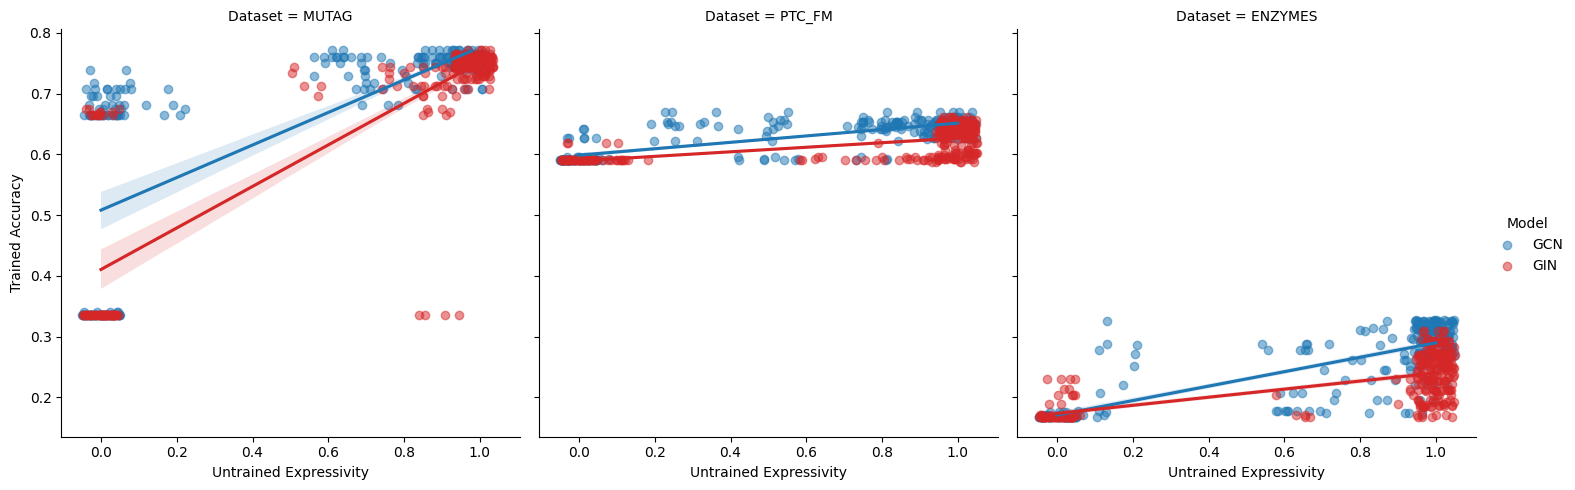

In [19]:
import scipy.stats as stats

palette = {'GCN': '#1f77b4', 'GIN': '#d62728'}

col_order = ["MUTAG", "PTC_FM", "ENZYMES"]

g = sns.lmplot(
    data=df_wide,
    x='Expressivity',
    y='Accuracy', 
    hue='Model',        
    col='Dataset',  
    col_order=col_order, 
    palette=palette,
    height=5,
    aspect=1,
    x_jitter=0.05,
    scatter_kws={'alpha': 0.5}
)

g.set_axis_labels("Untrained Expressivity", "Trained Accuracy")
plt.show()

In [ ]:
print("--- Pearson Correlation: Accuracy vs. Untrained Expressivity ---")

datasets = df_wide['Dataset'].unique()
models = df_wide['Model'].unique()

for ds in datasets:
    print(f"\nDataset: {ds}")
    for model in models:
        # Filter for dataset and model
        subset = df_wide[(df_wide['Dataset'] == ds) & (df_wide['Model'] == model)]
        
        # Calcualte Correlation
        if len(subset) > 1:
            corr, p_val = stats.pearsonr(subset['Expressivity'], subset['Accuracy'])
            print(f"  {model}: r = {corr:.3f} (p = {p_val:.5f})")

--- Pearson Correlation: Accuracy vs. Untrained Expressivity ---

Dataset: ENZYMES
  GCN: r = 0.837 (p = 0.00000)
  GIN: r = 0.663 (p = 0.00000)

Dataset: MUTAG
  GCN: r = 0.730 (p = 0.00000)
  GIN: r = 0.857 (p = 0.00000)

Dataset: PTC_FM
  GCN: r = 0.800 (p = 0.00000)
  GIN: r = 0.632 (p = 0.00000)
